In [1]:
# 1. Dependencies are already installed in the local .venv (torch, timm, opencv-python, scikit-learn, av, matplotlib, seaborn, psutil).
# Uncomment the line below only if running on a fresh environment:
# %pip install -q timm psutil opencv-python scikit-learn av matplotlib seaborn

In [2]:
import os
import gc
import cv2
import av
import time
import numpy as np
import torch
import torch.nn as nn
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

In [3]:
# 3. Test Ingestion Configuration (local paths, relative to this notebook's folder)
EVAL_CONFIG = {
    "resize_dim": (380, 380),
    "backbone_name": "efficientnet_b4",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "feature_dim": 1792,
    "target_seq_len": 12,
    "frames_per_gop": 4,       # Frames sampled per GOP chunk (matches training extraction)
    "neighborhood_gops": 3,    # Full peak neighborhood size used at HIGH priority
    "class_names": ["Non-Violence", "Violence"]  # 0 = NonViolent, 1 = Violent
}

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

# Local artifact paths
MODEL_WEIGHTS_PATH = Path("model/best_transformer_model.pth")
LOG_FILE_PATH = Path("model/training_audit_trail.md")
FINAL_TEST_PATH = "dataset/test"

# Dedicated target folder for visual output plots
PLOT_OUTPUT_DIR = Path("plots")
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# 4. Rebuild Transformer Architecture Framework
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=1792, num_heads=4, hidden_dim=256, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=0.2,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x_proj = self.input_proj(x)
        out = self.transformer(x_proj)
        pooled = torch.mean(out, dim=1)
        return self.fc(pooled).squeeze(-1)

In [5]:
# 5. Initialize EfficientNet Extraction Block
print("Initializing frozen EfficientNet-B4 extraction backbone...")
backbone = timm.create_model(EVAL_CONFIG["backbone_name"], pretrained=True)
backbone.reset_classifier(num_classes=0)
backbone.eval()
backbone.to(EVAL_CONFIG["device"])

print(f"Loading champion Transformer weights from: {MODEL_WEIGHTS_PATH}...")
classifier = TransformerClassifier()
classifier.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location="cpu"))
classifier.eval()
classifier.to(EVAL_CONFIG["device"])

print("\n🚀 Model loaded successfully. Ready for test set evaluation.")

Initializing frozen EfficientNet-B4 extraction backbone...


Loading champion Transformer weights from: model/best_transformer_model.pth...

🚀 Model loaded successfully. Ready for test set evaluation.


In [6]:
# 6. Peak-Motion GOP-Based Priority Inference
# Mirrors the training-time feature extraction: the video is decoded with PyAV and split
# into natural GOP chunks at codec keyframes, every GOP is motion-scored via grayscale
# frame differencing, and frames are drawn from the highest-motion region instead of
# being sampled uniformly across the timeline.
#
# Priority now controls how many GOP chunks around the motion peak are ingested:
#   low  -> 1 GOP  (4 frames:  the peak-motion GOP only)
#   mid  -> 2 GOPs (8 frames:  peak GOP + its higher-motion adjacent neighbor)
#   high -> 3 GOPs (12 frames: peak GOP +/- 1 neighbor — identical to training)
# The sampled frames are cyclically cloned up to the fixed 12-token sequence.

def decode_video_to_gop_chunks(video_path: str, resize_dim: tuple):
    """Decode with PyAV, splitting at true codec keyframes (same as feature extraction)."""
    container = av.open(video_path)
    stream = container.streams.video[0]
    stream.thread_type = 'AUTO'

    chunks = []
    current_chunk_rgb = []
    current_chunk_gray = []
    total_frames = 0

    for frame in container.decode(video=0):
        img_rgb = frame.to_ndarray(format='rgb24')
        total_frames += 1

        img_resized = cv2.resize(img_rgb, resize_dim, interpolation=cv2.INTER_AREA)
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

        if frame.key_frame and len(current_chunk_rgb) > 0:
            chunks.append({"rgb": current_chunk_rgb, "gray": current_chunk_gray})
            current_chunk_rgb = []
            current_chunk_gray = []

        current_chunk_rgb.append(img_resized)
        current_chunk_gray.append(img_gray)

    if len(current_chunk_rgb) > 0:
        chunks.append({"rgb": current_chunk_rgb, "gray": current_chunk_gray})

    container.close()
    if len(chunks) == 0:
        raise RuntimeError(f"Video container yielded 0 readable GOP structures: {video_path}")
    return chunks, total_frames


def uniform_sample_indices(n_available: int, n_target: int):
    if n_available <= 0:
        raise RuntimeError("Cannot compute indices on an empty chunk.")
    if n_available >= n_target:
        return np.linspace(0, n_available - 1, n_target).round().astype(int)
    base = np.arange(n_available)
    reps = int(np.ceil(n_target / n_available))
    return np.tile(base, reps)[:n_target]


def compute_motion_score(sampled_gray_frames):
    if len(sampled_gray_frames) < 2:
        return 0.0
    score = 0.0
    prev_gray = sampled_gray_frames[0]
    for curr_gray in sampled_gray_frames[1:]:
        diff = cv2.absdiff(curr_gray, prev_gray)
        score += float(np.sum(diff, dtype=np.float64))
        prev_gray = curr_gray
    return score


def select_neighborhood_chunk_indices(num_chunks: int, peak_idx: int, window: int = 3):
    if num_chunks < window:
        return None
    half = window // 2
    start = peak_idx - half
    end = start + window
    if start < 0:
        shift = -start
        start += shift
        end += shift
    if end > num_chunks:
        shift = end - num_chunks
        start -= shift
        end -= shift
    return list(range(max(0, start), min(num_chunks, end)))


def clone_frames_to_length(frames, target_len: int):
    if len(frames) == 0:
        raise RuntimeError("Cannot clone an empty frame list.")
    if len(frames) >= target_len:
        return frames[:target_len]
    reps = int(np.ceil(target_len / len(frames)))
    return (frames * reps)[:target_len]


def predict_video_priority(video_path: str, priority: str = "high"):
    """
    Peak-motion GOP inference under a priority budget.
    priority: 'low' (1 GOP / 4 frames), 'mid' (2 GOPs / 8 frames), 'high' (3 GOPs / 12 frames)
    """
    priority_gop_map = {"low": 1, "mid": 2, "high": 3}
    gop_budget = priority_gop_map.get(priority.lower(), 3)
    frames_per_gop = EVAL_CONFIG["frames_per_gop"]
    target_len = EVAL_CONFIG["target_seq_len"]

    try:
        chunks, total_frames = decode_video_to_gop_chunks(video_path, EVAL_CONFIG["resize_dim"])
    except RuntimeError as exc:
        return {"error": str(exc)}

    num_chunks = len(chunks)

    if num_chunks < gop_budget:
        # Short-video fallback: uniformly spread the frame budget over the full timeline
        all_rgb = [f for c in chunks for f in c["rgb"]]
        idxs = uniform_sample_indices(len(all_rgb), gop_budget * frames_per_gop)
        final_frames = [all_rgb[i] for i in idxs]
    else:
        # Score every GOP: 4 uniformly sampled grayscale frames -> summed absolute diffs
        motion_scores = []
        for c in chunks:
            idxs = uniform_sample_indices(len(c["gray"]), frames_per_gop)
            motion_scores.append(compute_motion_score([c["gray"][i] for i in idxs]))

        peak_idx = int(np.argmax(motion_scores))

        if gop_budget == 1:
            selected_idxs = [peak_idx]
        elif gop_budget == 2:
            left = peak_idx - 1 if peak_idx > 0 else None
            right = peak_idx + 1 if peak_idx < num_chunks - 1 else None
            if left is None:
                neighbor = right
            elif right is None:
                neighbor = left
            else:
                neighbor = left if motion_scores[left] >= motion_scores[right] else right
            selected_idxs = sorted([peak_idx, neighbor])
        else:
            selected_idxs = select_neighborhood_chunk_indices(
                num_chunks, peak_idx, window=EVAL_CONFIG["neighborhood_gops"]
            )

        final_frames = []
        for idx in selected_idxs:
            rep_idxs = uniform_sample_indices(len(chunks[idx]["rgb"]), frames_per_gop)
            final_frames.extend(chunks[idx]["rgb"][r_i] for r_i in rep_idxs)

    # Stretch the budgeted frames to the fixed 12-token sequence the Transformer expects
    final_frames = clone_frames_to_length(final_frames, target_len)

    # Convert tensor profiles and pass forward into networks
    batch = np.stack(final_frames, axis=0)
    batch_t = torch.from_numpy(batch).permute(0, 3, 1, 2).to(EVAL_CONFIG["device"], dtype=torch.float32)

    mean = IMAGENET_MEAN.to(EVAL_CONFIG["device"])
    std = IMAGENET_STD.to(EVAL_CONFIG["device"])
    batch_t = (batch_t / 255.0 - mean) / std

    with torch.no_grad():
        features = backbone(batch_t)
        features = features.unsqueeze(0)

        logits = classifier(features)
        probability = torch.sigmoid(logits).item()

    predicted_class = 1 if probability >= 0.5 else 0

    del batch_t, features, logits, final_frames, chunks
    return {"class_id": predicted_class, "probability": probability}

In [7]:
def run_independent_test_set_suite_with_plotting(test_dataset_root):
    import psutil  # Local import to guarantee availability

    root = Path(test_dataset_root)
    video_extensions = (".mp4", ".avi", ".mov", ".mkv")

    if not root.is_dir():
        print(f"❌ Error: The root test directory does not exist: {test_dataset_root}")
        return None, None

    all_subdirs = [d for d in root.iterdir() if d.is_dir()]
    violent_dir, non_violent_dir = None, None

    for d in all_subdirs:
        folder_name_lower = d.name.lower()
        if "non" in folder_name_lower:
            non_violent_dir = d
        elif "viol" in folder_name_lower:
            violent_dir = d

    if not violent_dir or not non_violent_dir:
        print(f"❌ Error: Could not automatically resolve your test class folders.")
        print(f"Found folders on your Drive: {[d.name for d in all_subdirs]}")
        return None, None

    class_mapping = {violent_dir: 1, non_violent_dir: 0}
    candidate_videos = []
    for folder_path, cls_id in class_mapping.items():
        for ext in video_extensions:
            candidate_videos.extend([(v, cls_id) for v in folder_path.glob(f"*{ext}")])
            candidate_videos.extend([(v, cls_id) for v in folder_path.glob(f"*{ext.upper()}")])

    if len(candidate_videos) == 0:
        print(f"❌ Error: Found the folders, but they contain 0 videos.")
        return None, None

    priority_profiles = ["low", "mid", "high"]
    suite_logs = []
    predictions_by_priority = {}

    print(f"🎬 EXECUTING TEST SET PRIORITY INVENTORY (Total Split Clips Identified: {len(candidate_videos)})")
    print("=" * 85)

    for priority in priority_profiles:
        print(f"\nEvaluating test set matrix behavior under '{priority.upper()}' priority constraints...")

        true_labels = []
        predicted_labels = []
        execution_latencies = []

        # Resource tracking lists for this specific priority level
        ram_usages = []
        vram_usages = []
        cpu_percentages = []

        # Reset max VRAM tracking to isolate statistics per priority run
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        for v_path, true_id in tqdm(candidate_videos, desc=f"Transformer Running ({priority.upper()})"):
            start_time = time.time()
            try:
                res = predict_video_priority(str(v_path), priority=priority)
                if "error" in res:
                    continue

                execution_latencies.append(time.time() - start_time)
                true_labels.append(true_id)
                predicted_labels.append(res["class_id"])

                # --- Dynamic System Resource Profiling ---
                # 1. Capture RAM (Convert Bytes to Gigabytes)
                current_ram = psutil.virtual_memory().used / (1024 ** 3)
                ram_usages.append(current_ram)

                # 2. Capture CPU load percentage
                cpu_percentages.append(psutil.cpu_percent())

                # 3. Capture GPU VRAM if CUDA backend is initialized
                if torch.cuda.is_available():
                    current_vram = torch.cuda.memory_allocated() / (1024 ** 3)
                    vram_usages.append(current_vram)
                else:
                    vram_usages.append(0.0)

            except Exception:
                continue

        if not true_labels:
            continue

        # Calculate metrics
        acc = accuracy_score(true_labels, predicted_labels)
        p, r, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average="macro", zero_division=0)

        # Calculate structural means for profiles
        avg_speed = np.mean(execution_latencies)
        avg_ram = np.mean(ram_usages)
        avg_cpu = np.mean(cpu_percentages)

        # Extract peak metrics to watch for hardware limitations
        peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 3) if torch.cuda.is_available() else 0.0

        print(f"📊 Summary [{priority.upper()}]: Accuracy: {acc:.4f} | F1: {f1:.4f} | Latency: {avg_speed:.3f}s | Avg RAM: {avg_ram:.2f}GB | Peak VRAM: {peak_vram:.2f}GB")

        suite_logs.append({
            "priority": priority.upper(),
            "accuracy": acc,
            "precision": p,
            "recall": r,
            "f1": f1,
            "latency": avg_speed,
            "avg_ram": avg_ram,
            "peak_vram": peak_vram,
            "avg_cpu": avg_cpu
        })

        predictions_by_priority[priority.upper()] = {
            "true": true_labels,
            "pred": predicted_labels
        }

    # --- Append Enhanced Performance Statistics to Google Drive Markdown File ---
    if LOG_FILE_PATH.exists():
        with open(LOG_FILE_PATH, "a") as log_f:
            log_f.write(f"\n## 📈 INDEPENDENT TEST SET PRIORITY RESOURCE & EFFICIENCY AUDIT\n")
            log_f.write(f"| Evaluation Level | Sampled Budget | Test Acc | F1-Score (Macro) | Inference Latency | Avg System RAM | Peak GPU VRAM | Avg CPU Load |\n")
            log_f.write(f"|---|---|---|---|---|---|---|---|\n")
            for log in suite_logs:
                f_desc = "4 frames" if log["priority"] == "LOW" else "8 frames" if log["priority"] == "MID" else "12 frames"
                log_f.write(
                    f"| {log['priority']} priority | {f_desc} | "
                    f"{log['accuracy']:.4f} | {log['f1']:.4f} | "
                    f"{log['latency']:.4f}s | {log['avg_ram']:.2f} GB | "
                    f"{log['peak_vram']:.2f} GB | {log['avg_cpu']:.1f}% |\n"
                )
            log_f.write(f"\n=========================== END OF INFRASTRUCTURE TIMELINE ===========================\n\n")

    return suite_logs, predictions_by_priority

In [8]:
# Run the evaluation cycle
metrics_summary, raw_predictions = run_independent_test_set_suite_with_plotting(FINAL_TEST_PATH)

🎬 EXECUTING TEST SET PRIORITY INVENTORY (Total Split Clips Identified: 200)

Evaluating test set matrix behavior under 'LOW' priority constraints...


Transformer Running (LOW):   0%|          | 0/200 [00:00<?, ?it/s]

📊 Summary [LOW]: Accuracy: 0.9150 | F1: 0.9150 | Latency: 2.628s | Avg RAM: 9.59GB | Peak VRAM: 0.00GB

Evaluating test set matrix behavior under 'MID' priority constraints...


Transformer Running (MID):   0%|          | 0/200 [00:00<?, ?it/s]

📊 Summary [MID]: Accuracy: 0.9450 | F1: 0.9450 | Latency: 2.625s | Avg RAM: 9.39GB | Peak VRAM: 0.00GB

Evaluating test set matrix behavior under 'HIGH' priority constraints...


Transformer Running (HIGH):   0%|          | 0/200 [00:00<?, ?it/s]

📊 Summary [HIGH]: Accuracy: 0.9400 | F1: 0.9400 | Latency: 2.615s | Avg RAM: 9.33GB | Peak VRAM: 0.00GB


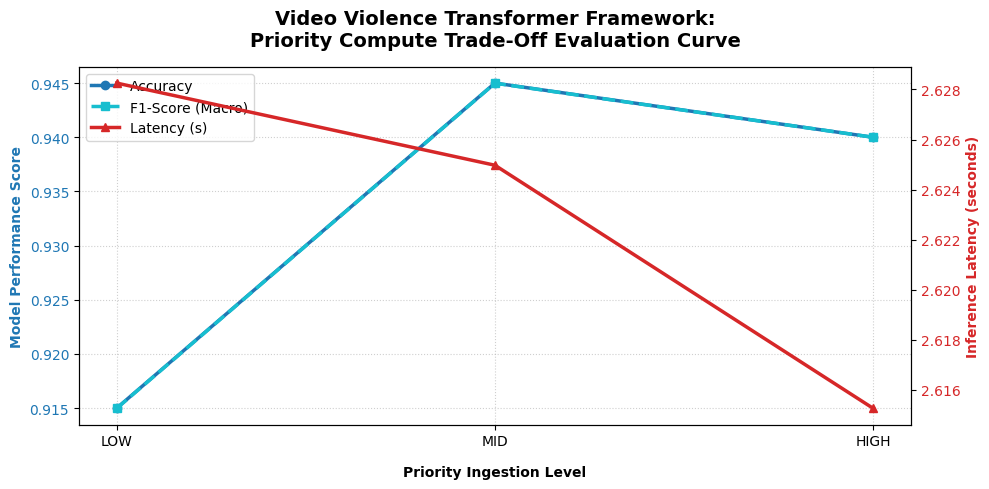

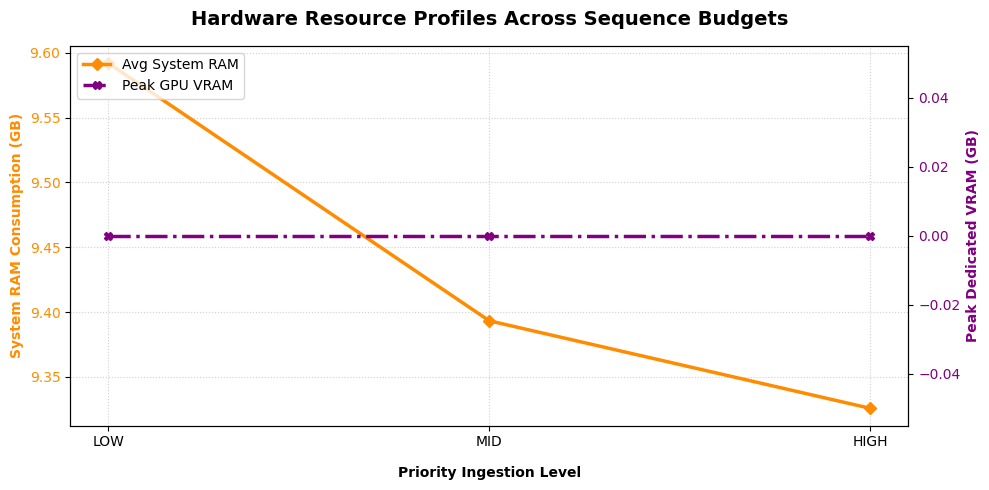

In [9]:
if metrics_summary:
    priorities = [log["priority"] for log in metrics_summary]
    accuracies = [log["accuracy"] for log in metrics_summary]
    f1_scores = [log["f1"] for log in metrics_summary]
    latencies = [log["latency"] for log in metrics_summary]
    ram_vals = [log["avg_ram"] for log in metrics_summary]
    vram_vals = [log["peak_vram"] for log in metrics_summary]

    # Plot A: Model Performance vs Latency (Your existing trade-off plot)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    color = 'tab:blue'
    ax1.set_xlabel('Priority Ingestion Level', fontweight='bold', labelpad=12)
    ax1.set_ylabel('Model Performance Score', color=color, fontweight='bold')
    line1 = ax1.plot(priorities, accuracies, marker='o', linewidth=2.5, color='tab:blue', label='Accuracy')
    line2 = ax1.plot(priorities, f1_scores, marker='s', linestyle='--', linewidth=2.5, color='tab:cyan', label='F1-Score (Macro)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle=':', alpha=0.6)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Inference Latency (seconds)', color=color, fontweight='bold')
    line3 = ax2.plot(priorities, latencies, marker='^', linewidth=2.5, color='tab:red', label='Latency (s)')
    ax2.tick_params(axis='y', labelcolor=color)

    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')
    plt.title('Video Violence Transformer Framework:\nPriority Compute Trade-Off Evaluation Curve', fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.savefig(PLOT_OUTPUT_DIR / "priority_tradeoff_curve.png", dpi=300)
    plt.show()

    # --- Plot B: Resource Consumption Tracking (NEW) ---
    fig, ax3 = plt.subplots(figsize=(10, 5))
    color = 'darkorange'
    ax3.set_xlabel('Priority Ingestion Level', fontweight='bold', labelpad=12)
    ax3.set_ylabel('System RAM Consumption (GB)', color=color, fontweight='bold')
    line_ram = ax3.plot(priorities, ram_vals, marker='D', linewidth=2.5, color='darkorange', label='Avg System RAM')
    ax3.tick_params(axis='y', labelcolor=color)
    ax3.grid(True, linestyle=':', alpha=0.6)

    ax4 = ax3.twinx()
    color = 'purple'
    ax4.set_ylabel('Peak Dedicated VRAM (GB)', color=color, fontweight='bold')
    line_vram = ax4.plot(priorities, vram_vals, marker='X', linestyle='-.', linewidth=2.5, color='purple', label='Peak GPU VRAM')
    ax4.tick_params(axis='y', labelcolor=color)

    res_lines = line_ram + line_vram
    res_labels = [l.get_label() for l in res_lines]
    ax3.legend(res_lines, res_labels, loc='upper left')

    plt.title('Hardware Resource Profiles Across Sequence Budgets', fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.savefig(PLOT_OUTPUT_DIR / "hardware_resource_profiles.png", dpi=300)
    plt.show()

🎯 Confusion matrix grid saved securely to: plots/priority_confusion_matrices.png


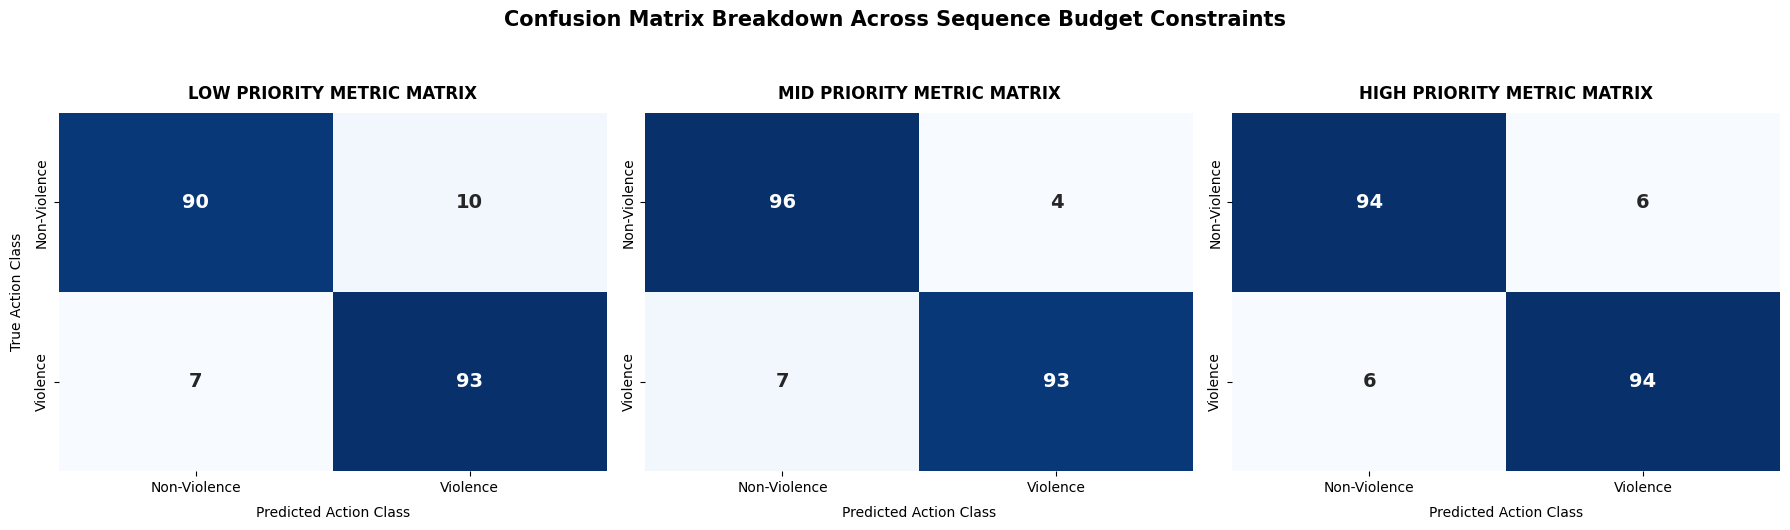

In [10]:
if raw_predictions:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    class_labels = EVAL_CONFIG["class_names"]

    for idx, priority in enumerate(["LOW", "MID", "HIGH"]):
        if priority in raw_predictions:
            true = raw_predictions[priority]["true"]
            pred = raw_predictions[priority]["pred"]

            cm = confusion_matrix(true, pred)

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                        xticklabels=class_labels, yticklabels=class_labels, ax=axes[idx],
                        annot_kws={"size": 14, "weight": "bold"})

            axes[idx].set_title(f'{priority} PRIORITY METRIC MATRIX', fontsize=12, fontweight='bold', pad=10)
            axes[idx].set_xlabel('Predicted Action Class', labelpad=8)
            if idx == 0:
                axes[idx].set_ylabel('True Action Class', labelpad=8)

    plt.suptitle('Confusion Matrix Breakdown Across Sequence Budget Constraints', fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()

    # Save the multi-matrix visualization layout
    matrix_save_path = PLOT_OUTPUT_DIR / "priority_confusion_matrices.png"
    plt.savefig(matrix_save_path, dpi=300, bbox_inches='tight')
    print(f"🎯 Confusion matrix grid saved securely to: {matrix_save_path}")
    plt.show()